MLP autoencoder with the following layers:

Encoder and Decoder:

| Layer type    | Input size     | Output size |
|---------------|--------------|------------|
| linear + relu | # of pixels      | 100    |
| linear        | 100      | bottleneck_size    |
| linear + relu | bottleneck_size      | 100    |
| linear        | 100      | # of pixels    |


### Import relevant packages

In [ ]:
import torch
from torch import nn
from torch.utils.data import DataLoader
from torchvision import datasets
from torchvision.transforms import ToTensor
import matplotlib.pyplot as plt

### Download training data from open datasets




In [ ]:
# Download training data from open datasets.
training_data = datasets.MNIST(
    root="data",
    train=True,
    download=True,
    transform=ToTensor(),
)

# Download test data from open datasets.
test_data = datasets.MNIST(
    root="data",
    train=False,
    download=True,
    transform=ToTensor(),
)

### Dividing training data into train and validations sets


In [ ]:
from torch.utils.data import random_split
train_size = int(0.9 * len(training_data))  # 90% training
val_size = len(training_data) - train_size  # 10% validation

train_dataset, val_dataset = random_split(training_data, [train_size, val_size])



### Setting up the data sets for training and testing

Shape of X [N, C, H, W]: torch.Size([512, 1, 28, 28])
Shape of y: torch.Size([512]) torch.int64


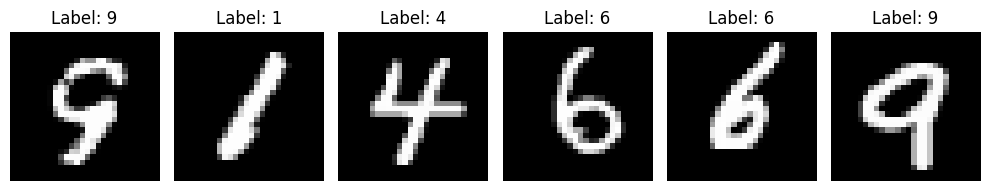

In [ ]:
batch_size = 512 # we will talk about it later

# Create data loaders.
train_dataloader = DataLoader(train_dataset, batch_size=batch_size)
val_dataloader = DataLoader(val_dataset, batch_size=batch_size)
test_dataloader = DataLoader(test_data, batch_size=batch_size)

for X, y in train_dataloader:
    print(f"Shape of X [N, C, H, W]: {X.shape}")
    print(f"Shape of y: {y.shape} {y.dtype}")

    fig, axes = plt.subplots(1, 6, figsize=(10, 10))
    axes = axes.flatten()

    for i in range(6):
        img = X[i].squeeze().numpy()
        axes[i].imshow(img, cmap="gray")
        axes[i].set_title(f"Label: {y[i]}")
        axes[i].axis('off')

    plt.tight_layout()
    plt.show()

    break

### Defining the MLP autoencoder




In [ ]:
# Get cpu, gpu or mps device for training.
device = (
    "cuda" if torch.cuda.is_available()
     else "cpu"
)
print(f"Using {device} device")

# Define model
class NeuralNetwork(nn.Module):
    def __init__(self):
        super().__init__()
        # Encoder
        self.encoder = nn.Sequential(
            nn.Linear(28*28, 100),
            nn.ReLU(),
            nn.Linear(100, 2),
        )
        # latent mean and variance
        self.mean_layer = nn.Linear(2, 2)
        self.logvar_layer = nn.Linear(2, 2)

        # Decoder
        self.decoder = nn.Sequential(
            nn.Linear(2, 100),  # Linear layer with 100 neurons
            nn.ReLU(),                       # ReLU activation
            nn.Linear(100, 28*28),        # Linear layer to reconstruct original size
            nn.Sigmoid()    # since the MNIST digits are between 0 and 1, here i'll use a sigmoid function at the output
        )

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)           # Convert log variance to standard deviation
        eps = torch.randn_like(std)             # Sample epsilon (noise) from normal distribution
        return mu + (eps * std)                 # Reparameterization trick


    def forward(self, x):
        x = x.view(x.size(0), -1)  # Flatten input since it's an MLP
        encoded = self.encoder(x)  # Get latent (encoded) representation

        mu = self.mean_layer(encoded)           # Mean of the latent space
        logvar = self.logvar_layer(encoded)     # Log variance of the latent space

        z = self.reparameterize(mu, logvar)

        decoded = self.decoder(z)  # Decode the latent representation
        return mu, logvar, decoded

model = NeuralNetwork().to(device)
print(model)


Using cpu device
NeuralNetwork(
  (encoder): Sequential(
    (0): Linear(in_features=784, out_features=100, bias=True)
    (1): ReLU()
    (2): Linear(in_features=100, out_features=2, bias=True)
  )
  (mean_layer): Linear(in_features=2, out_features=2, bias=True)
  (logvar_layer): Linear(in_features=2, out_features=2, bias=True)
  (decoder): Sequential(
    (0): Linear(in_features=2, out_features=100, bias=True)
    (1): ReLU()
    (2): Linear(in_features=100, out_features=784, bias=True)
    (3): Sigmoid()
  )
)


Sanity check for the model with a forward pass with a random input

In [ ]:
input = torch.randn(4, 28*28).to(device)  # Example random input with batch size 4

# Pass the data through the model
mu, logvar, decoded = model(input)

# `encoded` will contain the latent representations (output from the encoder)
# `decoded` will contain the reconstructed output (output from the decoder)
print("Encoded output (mu):", mu)
print("Encoded output (logvar):", logvar)

print("Decoded output (reconstruction):", decoded)


Encoded output (mu): tensor([[-0.4896, -0.5510],
        [-0.3978, -0.4887],
        [-0.4054, -0.5583],
        [-0.3182, -0.7473]], grad_fn=<AddmmBackward0>)
Encoded output (logvar): tensor([[ 0.8839, -0.2711],
        [ 0.6859, -0.2195],
        [ 0.7335, -0.2669],
        [ 0.6656, -0.3841]], grad_fn=<AddmmBackward0>)
Decoded output (reconstruction): tensor([[0.4131, 0.5707, 0.4286,  ..., 0.6198, 0.6445, 0.4322],
        [0.4646, 0.5271, 0.5134,  ..., 0.5671, 0.5860, 0.4774],
        [0.4571, 0.5230, 0.5452,  ..., 0.5904, 0.5858, 0.4613],
        [0.4370, 0.5358, 0.6192,  ..., 0.6412, 0.5803, 0.4212]],
       grad_fn=<SigmoidBackward0>)


### Defining a loss-function
Since we want the output to be as close as possible to the input, I will choose MSE as the loss function.




In [ ]:
def vae_loss_function(recon_x, x, mu, logvar):
    # Reconstruction loss (BCE or MSE)
    recon_loss = nn.functional.mse_loss(recon_x, x.view(-1, 28*28), reduction='sum')

    # KL Divergence loss
    kl_divergence = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())

    # Total loss = reconstruction + KL divergence
    return recon_loss + kl_divergence

optimizer = torch.optim.Adam(model.parameters(), lr=1e-3) # Adam optimizer

In [ ]:
train_losses = []
test_losses = []

def train(dataloader, model, loss_fn, optimizer):
    size = len(dataloader.dataset)
    model.train()
    total_loss = 0  # Track the total loss for the epoch

    for batch, (X, _) in enumerate(dataloader):
        X = X.to(device)

        # Compute prediction error
        mu, logvar, decoded = model(X)
        loss = loss_fn(decoded, X.view(X.size(0), -1), mu, logvar)
        total_loss += loss.item()  # Accumulate loss

        # Backpropagation
        loss.backward()
        optimizer.step()
        optimizer.zero_grad()

        if batch % 100 == 0:
            loss, current = loss.item(), (batch + 1) * len(X)
            print(f"loss: {loss:>7f}  [{current:>5d}/{size:>5d}]")
    avg_loss = total_loss / len(dataloader)  # Calculate average loss for the epoch


    train_losses.append(avg_loss)  # Store the average loss for the epoch


    print(f"Train loss: {avg_loss:>7f}\n")


In [ ]:
def test(dataloader, model, loss_fn):
    size = len(dataloader.dataset)
    num_batches = len(dataloader)
    model.eval()
    test_loss = 0
    with torch.no_grad():
        for X, _ in dataloader:
            X = X.to(device)
            mu, logvar, decoded = model(X)
            test_loss += loss_fn(decoded, X.view(X.size(0), -1), mu, logvar).item()
    test_loss /= num_batches
    test_losses.append(test_loss)  # Store the test loss for the epoch

    print(f"Test Error: \n Avg loss: {test_loss:>8f}\n")
    return test_loss

In [ ]:
epochs = 100
patience = 5
best_loss = float('inf')
early_stopping_counter = 0

for t in range(epochs):
    print(f"Epoch {t+1}\n-------------------------------")
    train(train_dataloader, model, vae_loss_function, optimizer)
    current_val_loss = test(val_dataloader, model, vae_loss_function) # this is used for validation data for early stopping
    if current_val_loss < best_loss:
        best_loss = current_val_loss  # Update best loss
        early_stopping_counter = 0  # Reset counter
        print(f"Val loss improved to {best_loss:.6f}, saving model...")
        torch.save(model.state_dict(), "VAE_best_model.pth")  # Save best model
    else:
        early_stopping_counter += 1
        print(f"No improvement in val loss. Early stopping counter: {early_stopping_counter}/{patience}")

    # If the patience counter reaches the patience threshold, stop training
    if early_stopping_counter >= patience:
        print("Early stopping triggered. Stopping training.")
        break

print("Done!")


Epoch 1
-------------------------------
loss: 95478.234375  [  512/54000]
loss: 30634.744141  [51712/54000]
Train loss: 41967.882702

Test Error: 
 Avg loss: 29946.489095

Val loss improved to 29946.489095, saving model...
Epoch 2
-------------------------------
loss: 31085.031250  [  512/54000]
loss: 28049.353516  [51712/54000]
Train loss: 29037.576421

Test Error: 
 Avg loss: 27448.602865

Val loss improved to 27448.602865, saving model...
Epoch 3
-------------------------------
loss: 28210.603516  [  512/54000]
loss: 26560.998047  [51712/54000]
Train loss: 27168.855377

Test Error: 
 Avg loss: 26268.225423

Val loss improved to 26268.225423, saving model...
Epoch 4
-------------------------------
loss: 26948.093750  [  512/54000]
loss: 26034.533203  [51712/54000]
Train loss: 26342.846394

Test Error: 
 Avg loss: 25655.601888

Val loss improved to 25655.601888, saving model...
Epoch 5
-------------------------------
loss: 26575.242188  [  512/54000]
loss: 25101.619141  [51712/54000]


# Check the performance of the network through train and test loss and accuracy curves

Write your code below to plot the training and test loss and accuracy for each epoch.

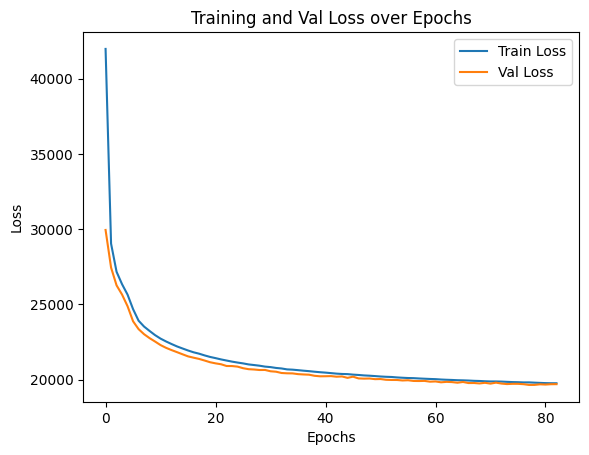

In [ ]:
plt.plot(train_losses, label="Train Loss")
plt.plot(test_losses, label="Val Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training and Val Loss over Epochs")
plt.legend()
plt.show()




# Check result for one image

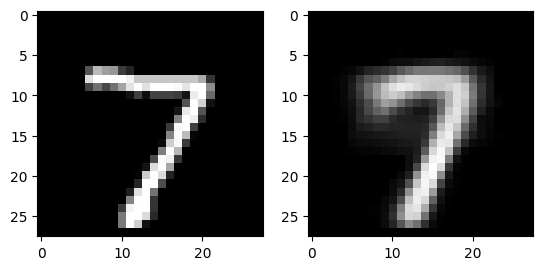

In [ ]:
model.eval()
idx = 0
x, y = test_data[idx][0], test_data[idx][1]
plt.subplot(1,2,1)
plt.imshow(x.permute(1,2,0), cmap = 'gray')
with torch.no_grad():
    x = x.to(device)
    mu, logvar, decoded = model(x.unsqueeze(0))
    decoded_image = decoded[0,].view(28, 28)
    plt.subplot(1,2,2)
    plt.imshow(decoded_image, cmap = 'gray')




### get encodings for all test data and display it




In [ ]:
all_encodings_mean = []
all_labels = []

model.eval()
with torch.no_grad():
    for batch in test_dataloader:
        X, y = batch
        X = X.to(device)
        mu, logvar, _ = model(X)
        all_encodings_mean.append(mu.cpu())
        all_labels.append(y.cpu())

all_encodings = torch.cat(all_encodings_mean)
all_labels = torch.cat(all_labels)

print("Shape of all encodings:", all_encodings.shape)
print("Shape of all encodings:", all_labels.shape)


Shape of all encodings: torch.Size([10000, 2])
Shape of all encodings: torch.Size([10000])


Plotting the encodings color coded with the relevant digit

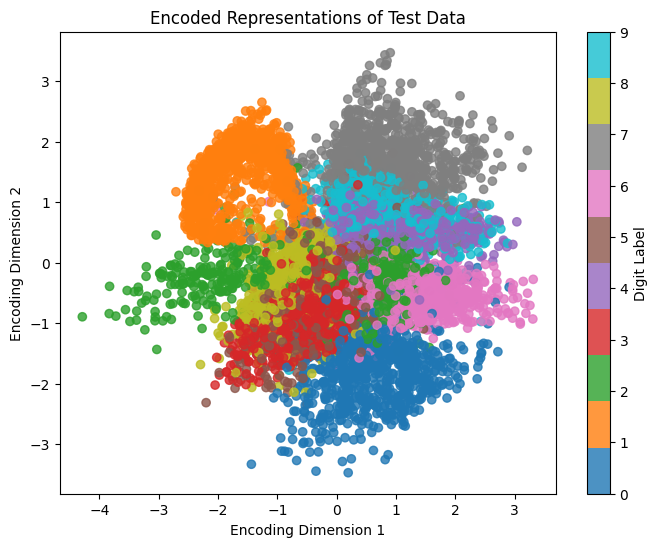

In [ ]:
encodings_np = all_encodings.numpy()
labels_np = all_labels.numpy()
plt.figure(figsize=(8, 6))
scatter = plt.scatter(encodings_np[:, 0], encodings_np[:, 1], c=labels_np, cmap='tab10', alpha=0.8, vmin = 0, vmax = 9)
plt.colorbar(scatter, label="Digit Label")
plt.title("Encoded Representations of Test Data")
plt.xlabel("Encoding Dimension 1")
plt.ylabel("Encoding Dimension 2")
plt.show()


Input own encodings to see what outputs we get

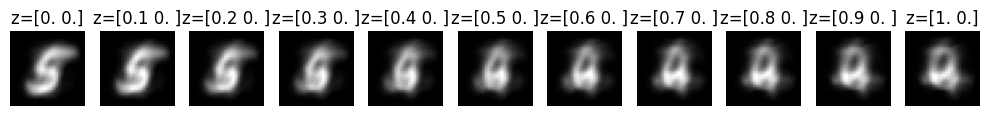

In [ ]:
encoded_values_list = [
    torch.tensor([[0.0, 0.0]], dtype=torch.float32),
    torch.tensor([[0.1, 0.0]], dtype=torch.float32),
    torch.tensor([[0.2, 0.0]], dtype=torch.float32),
    torch.tensor([[0.3, 0.0]], dtype=torch.float32),
    torch.tensor([[0.4, 0.0]], dtype=torch.float32),
    torch.tensor([[0.5, 0.0]], dtype=torch.float32),
    torch.tensor([[0.6, 0.0]], dtype=torch.float32),
    torch.tensor([[0.7, 0.0]], dtype=torch.float32),
    torch.tensor([[0.8, 0.0]], dtype=torch.float32),
    torch.tensor([[0.9, 0.0]], dtype=torch.float32),
    torch.tensor([[1.0, 0.0]], dtype=torch.float32)
]

# Make sure the model is in evaluation mode
model.eval()

fig, axes = plt.subplots(1, len(encoded_values_list), figsize=(10, 3))

for i, encoded_values in enumerate(encoded_values_list):
    with torch.no_grad():
        decoded_output = model.decoder(encoded_values)  # Decode the given encoded values
        decoded_image = decoded_output.view(28, 28).cpu()  # Reshape to image size (28x28 for MNIST)

    axes[i].imshow(decoded_image, cmap='gray')
    axes[i].set_title(f"z={encoded_values.numpy()[0]}")
    axes[i].axis('off')

plt.tight_layout()
plt.show()
